# Exploratory Statistical Testing of Functional Connectivity Differences

## Goal

This notebook performs exploratory statistical testing of functional connectivity differences between diagnostic groups and healthy controls.

The current sample size is small, so the results are intended to demonstrate the analysis workflow rather than provide clinical or scientific conclusions.


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nilearn import datasets, plotting

PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.statistics import (
    vectorize_upper_triangle,
    reconstruct_symmetric_matrix,
    permutation_group_comparison,
)

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
CONNECTIVITY_DIR = PROCESSED_DIR / "connectivity"


## Load group connectivity results

In [2]:
results_path = PROCESSED_DIR / "group_connectivity_results.tsv"

results_df = pd.read_csv(results_path, sep="\t")

results_df


,participant_id,diagnosis,time_series_shape,matrix_shape,status
0,sub-70060,ADHD,"(152, 48)","(48, 48)",success
1,sub-60022,BIPOLAR,"(152, 48)","(48, 48)",success
2,sub-10347,CONTROL,"(152, 48)","(48, 48)",success
3,sub-50023,SCHZ,"(152, 48)","(48, 48)",success


In [3]:
successful_subjects = results_df[results_df["status"] == "success"].copy()

successful_subjects["diagnosis"].value_counts()


diagnosis
ADHD       1
BIPOLAR    1
CONTROL    1
SCHZ       1
Name: count, dtype: int64

## Load ROI labels

In [4]:
atlas = datasets.fetch_atlas_harvard_oxford(
    atlas_name="cort-maxprob-thr25-2mm"
)

roi_labels = atlas.labels[1:]

print(f"Number of ROI labels: {len(roi_labels)}")
print(roi_labels[:10])


[fetch_atlas_harvard_oxford] Dataset found in C:\Users\vi\nilearn_data\fsl
Number of ROI labels: 48
['Frontal Pole', 'Insular Cortex', 'Superior Frontal Gyrus', 'Middle Frontal Gyrus', 'Inferior Frontal Gyrus, pars triangularis', 'Inferior Frontal Gyrus, pars opercularis', 'Precentral Gyrus', 'Temporal Pole', 'Superior Temporal Gyrus, anterior division', 'Superior Temporal Gyrus, posterior division']


## Load subject-level connectivity matrices

In [5]:
matrices = {}

for _, row in successful_subjects.iterrows():
    subject_id = row["participant_id"]
    matrix_path = CONNECTIVITY_DIR / f"{subject_id}_connectivity_matrix.npy"
    
    if matrix_path.exists():
        matrices[subject_id] = np.load(matrix_path)
    else:
        print(f"Missing matrix for {subject_id}: {matrix_path}")

print(f"Loaded matrices: {len(matrices)}")


Loaded matrices: 4


## Vectorize connectivity matrices

In [6]:
vectors = {}
triu_indices = None
matrix_size = None

for subject_id, matrix in matrices.items():
    vector, current_triu_indices = vectorize_upper_triangle(matrix)
    vectors[subject_id] = vector
    
    if triu_indices is None:
        triu_indices = current_triu_indices
        matrix_size = matrix.shape[0]

print(f"Number of edges per subject: {len(next(iter(vectors.values())))}")
print(f"Matrix size: {matrix_size} × {matrix_size}")


Number of edges per subject: 1128
Matrix size: 48 × 48


## Prepare group arrays

In [7]:
group_vectors = {}

for diagnosis, group_df in successful_subjects.groupby("diagnosis"):
    subject_ids = group_df["participant_id"].tolist()
    available_subject_ids = [subject_id for subject_id in subject_ids if subject_id in vectors]
    
    group_vectors[diagnosis] = np.vstack([
        vectors[subject_id] for subject_id in available_subject_ids
    ])
    
    print(f"{diagnosis}: {group_vectors[diagnosis].shape}")


ADHD: (1, 1128)
BIPOLAR: (1, 1128)
CONTROL: (1, 1128)
SCHZ: (1, 1128)


In [8]:
list(group_vectors.keys())


['ADHD', 'BIPOLAR', 'CONTROL', 'SCHZ']

## Permutation testing against healthy controls

In [9]:
control_label = "CONTROL"

if control_label not in group_vectors:
    raise ValueError(f"Control group '{control_label}' not found. Available groups: {list(group_vectors.keys())}")

comparison_results = {}

for diagnosis, patient_vectors in group_vectors.items():
    if diagnosis == control_label:
        continue
    
    print(f"Comparing {diagnosis} vs {control_label}")
    
    results = permutation_group_comparison(
        control_vectors=group_vectors[control_label],
        patient_vectors=patient_vectors,
        roi_labels=roi_labels,
        triu_indices=triu_indices,
        n_permutations=1000,
        alpha=0.05,
        random_state=42,
    )
    
    comparison_results[diagnosis] = results
    
    display(results.head(10))


Comparing ADHD vs CONTROL


,roi_1,roi_2,mean_control,mean_patient,mean_difference,abs_mean_difference,p_value_permutation,p_fdr,significant_fdr
0,Subcallosal Cortex,Occipital Pole,-0.243689,0.669997,0.913686,0.913686,1.0,1.0,False
1,Intracalcarine Cortex,Subcallosal Cortex,-0.273185,0.614062,0.887247,0.887247,1.0,1.0,False
2,"Middle Temporal Gyrus, temporooccipital part",Subcallosal Cortex,-0.201522,0.602645,0.804167,0.804167,1.0,1.0,False
3,Subcallosal Cortex,Cuneal Cortex,-0.390149,0.410510,0.800658,0.800658,1.0,1.0,False
4,Subcallosal Cortex,Supracalcarine Cortex,-0.352589,0.419765,0.772354,0.772354,1.0,1.0,False
5,Subcallosal Cortex,Occipital Fusiform Gyrus,-0.224348,0.544573,0.768921,0.768921,1.0,1.0,False
6,Angular Gyrus,Subcallosal Cortex,-0.195914,0.542885,0.738798,0.738798,1.0,1.0,False
7,Frontal Pole,Juxtapositional Lobule Cortex (formerly Supple...,0.626454,-0.105516,-0.731970,0.731970,1.0,1.0,False
8,Frontal Pole,Planum Temporale,0.598653,-0.128633,-0.727286,0.727286,1.0,1.0,False
9,Frontal Pole,Parietal Opercular Cortex,0.544401,-0.179377,-0.723778,0.723778,1.0,1.0,False


Comparing BIPOLAR vs CONTROL


,roi_1,roi_2,mean_control,mean_patient,mean_difference,abs_mean_difference,p_value_permutation,p_fdr,significant_fdr
0,Temporal Pole,"Middle Temporal Gyrus, temporooccipital part",0.042146,0.773574,0.731428,0.731428,1.0,1.0,False
1,Temporal Pole,Heschl's Gyrus (includes H1 and H2),0.019776,0.684690,0.664914,0.664914,1.0,1.0,False
2,Subcallosal Cortex,Cuneal Cortex,-0.390149,0.214796,0.604945,0.604945,1.0,1.0,False
3,Temporal Pole,"Parahippocampal Gyrus, anterior division",0.140005,0.736120,0.596116,0.596116,1.0,1.0,False
4,Temporal Pole,Cuneal Cortex,-0.005260,0.590183,0.595443,0.595443,1.0,1.0,False
5,Temporal Occipital Fusiform Cortex,Occipital Pole,0.711560,0.137086,-0.574474,0.574474,1.0,1.0,False
6,Temporal Pole,"Temporal Fusiform Cortex, posterior division",0.137862,0.707345,0.569483,0.569483,1.0,1.0,False
7,Lingual Gyrus,Occipital Pole,0.731858,0.163199,-0.568660,0.568660,1.0,1.0,False
8,Intracalcarine Cortex,"Temporal Fusiform Cortex, anterior division",-0.101888,0.439438,0.541326,0.541326,1.0,1.0,False
9,Precentral Gyrus,"Middle Temporal Gyrus, temporooccipital part",0.290715,0.827488,0.536774,0.536774,1.0,1.0,False


Comparing SCHZ vs CONTROL


,roi_1,roi_2,mean_control,mean_patient,mean_difference,abs_mean_difference,p_value_permutation,p_fdr,significant_fdr
0,Middle Frontal Gyrus,"Inferior Temporal Gyrus, posterior division",0.675828,-0.392772,-1.068600,1.068600,1.0,1.0,False
1,"Inferior Temporal Gyrus, posterior division","Supramarginal Gyrus, posterior division",0.745571,-0.267229,-1.012800,1.012800,1.0,1.0,False
2,"Inferior Temporal Gyrus, anterior division",Frontal Opercular Cortex,0.565935,-0.432336,-0.998271,0.998271,1.0,1.0,False
3,"Inferior Temporal Gyrus, anterior division","Supramarginal Gyrus, posterior division",0.574915,-0.357583,-0.932497,0.932497,1.0,1.0,False
4,Frontal Orbital Cortex,Occipital Pole,0.468780,-0.439603,-0.908383,0.908383,1.0,1.0,False
5,Middle Frontal Gyrus,"Inferior Temporal Gyrus, anterior division",0.528347,-0.369260,-0.897607,0.897607,1.0,1.0,False
6,Superior Frontal Gyrus,"Inferior Temporal Gyrus, posterior division",0.630588,-0.242385,-0.872973,0.872973,1.0,1.0,False
7,"Inferior Frontal Gyrus, pars triangularis",Occipital Pole,0.441555,-0.413000,-0.854555,0.854555,1.0,1.0,False
8,"Inferior Temporal Gyrus, posterior division",Occipital Pole,0.431605,-0.418658,-0.850263,0.850263,1.0,1.0,False
9,"Middle Temporal Gyrus, temporooccipital part","Inferior Temporal Gyrus, anterior division",0.553607,-0.293574,-0.847181,0.847181,1.0,1.0,False


## Visualize mean difference matrices

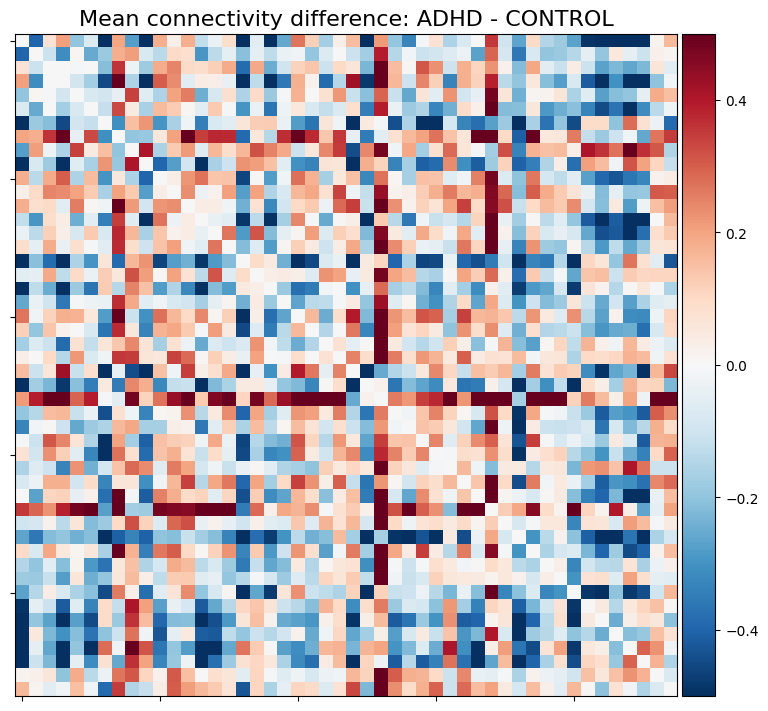

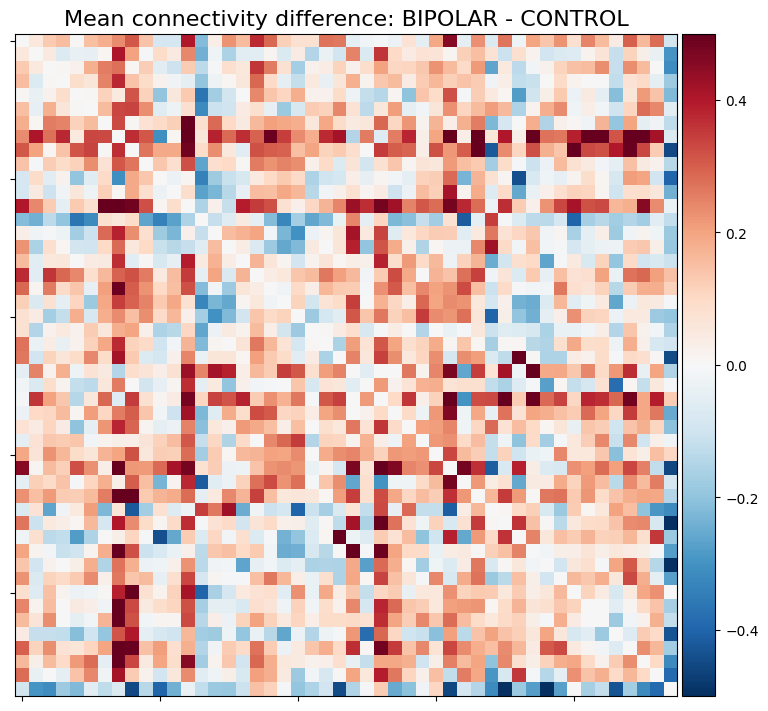

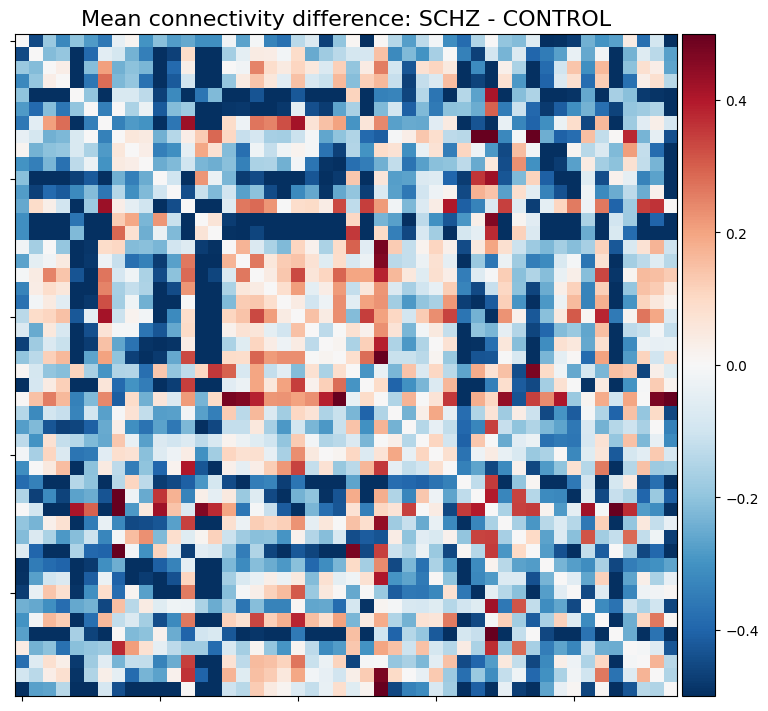

In [10]:
for diagnosis in comparison_results.keys():
    mean_patient = np.nanmean(group_vectors[diagnosis], axis=0)
    mean_control = np.nanmean(group_vectors[control_label], axis=0)
    mean_difference_vector = mean_patient - mean_control
    
    difference_matrix = reconstruct_symmetric_matrix(
        vector=mean_difference_vector,
        triu_indices=triu_indices,
        matrix_size=matrix_size,
    )
    
    plotting.plot_matrix(
        difference_matrix,
        figure=(8, 7),
        vmin=-0.5,
        vmax=0.5,
        reorder=False,
        title=f"Mean connectivity difference: {diagnosis} - {control_label}",
    )
    
    plt.show()


## FDR-significant edges

In [11]:
for diagnosis, results in comparison_results.items():
    n_significant = results["significant_fdr"].sum()
    print(f"{diagnosis}: {n_significant} FDR-significant edges")
    
    if n_significant > 0:
        display(results[results["significant_fdr"]].head(20))


ADHD: 0 FDR-significant edges
BIPOLAR: 0 FDR-significant edges
SCHZ: 0 FDR-significant edges


## Save statistical results

In [12]:
stats_dir = PROCESSED_DIR / "statistics"
stats_dir.mkdir(parents=True, exist_ok=True)

for diagnosis, results in comparison_results.items():
    output_path = stats_dir / f"permutation_statistics_{diagnosis}_vs_{control_label}.tsv"
    results.to_csv(output_path, sep="\t", index=False)
    print(f"Saved: {output_path}")


Saved: C:\Users\vi\psychiatric-brain-connectivity-analysis\data\processed\statistics\permutation_statistics_ADHD_vs_CONTROL.tsv
Saved: C:\Users\vi\psychiatric-brain-connectivity-analysis\data\processed\statistics\permutation_statistics_BIPOLAR_vs_CONTROL.tsv
Saved: C:\Users\vi\psychiatric-brain-connectivity-analysis\data\processed\statistics\permutation_statistics_SCHZ_vs_CONTROL.tsv


## Summary

This notebook implemented an exploratory statistical workflow for functional connectivity differences.

Completed steps:

- loaded subject-level connectivity matrices;
- vectorized ROI-to-ROI connectivity matrices;
- compared diagnostic groups against healthy controls;
- performed edge-wise permutation testing;
- applied Benjamini-Hochberg FDR correction;
- saved edge-wise statistical results.

Important limitation:

The current sample size is too small for clinical or scientific conclusions. The purpose of this notebook is to demonstrate a reproducible statistical workflow that can be scaled to larger samples.
